<a href="https://colab.research.google.com/github/Thomas-Fabbris/MMIP-polimi/blob/main/Assignments/lecture_4_limitations_of_sparsity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
from matplotlib import pyplot as plt
import scipy as sp
from scipy.fftpack import idct

Set the random number generator seed for ensuring reproducibility of results 
across multiple executions

In [ ]:
np.random.seed(42)

Variable initialization

In [ ]:
N = 32  # signal dimension
M = 32  # number of atoms in the span (for basis M = N)

# Matrix containing the standard basis (a kronecker delta in each column)
C = np.zeros((N, M))
# Matrix containing the DCT basis (a DCT function in each column)
D = np.zeros((N, M))

Generate the 1D-DCT basis

Text(0.5, 1.0, 'DCT Basis (N = 32)')

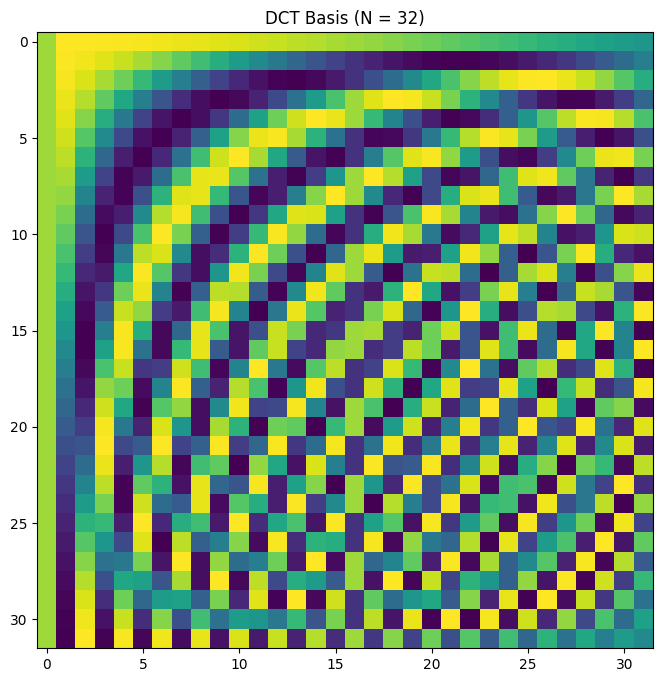

In [4]:
# Initialization of C and of D
for i in range(M):
    C[i, i] = 1.0
    D[:, i] = idct(C[:, i], norm='ortho')

plt.figure(figsize=(8, 8))
plt.imshow(D)
plt.title(f'DCT Basis (N = {M})')

# Sparsity w.r.t orthonormal basis DCT

In this section you will perform denoising of a signal that is *sparse* w.r.t. the orthornormal basis $D\in\mathbb{R}^{N\times N}$, i.e., the 1D-DCT basis.

At first, generate a vector $x_{orig}\in\mathbb{R}^N$ that is $L$-sparse, i.e. $\|x_{orig}\|_0 = L$. Using this coefficient vector $x_{orig}$, generate a noise-free signal $y\in\mathbb{R}^N$ as $y=Dx_{orig}$, and add some Gaussian noise to obtain $s = y + \eta$.

Perform the DCT denoising on the noisy signal $s$ to recover $\hat y$. Use the Hard Thresholding operator that keeps only the largest $L$ coefficients and evaluate the denoising performance


Set the sparsity level $L$

In [ ]:
L = 3

Randomly define the coefficients of a sparse representation $x$ (make sure the nonzero coefficients are sufficiently large)

In [ ]:
x_orig = np.zeros(N)
# Select the indices of the non-zero elements
idxs = np.random.choice(M, L, replace=False)
# Randomly generate the non-zero coefficients
x_orig[idxs] = np.random.uniform(-1.0, 1.0, size=(L,))

Synthetize the corresponding signal in the signal domain and add noise


In [ ]:
y = D @ x_orig
sigma_noise = 0.1
s = y + np.random.normal(0.0, sigma_noise, size=(M,))

Plot the sparse signal

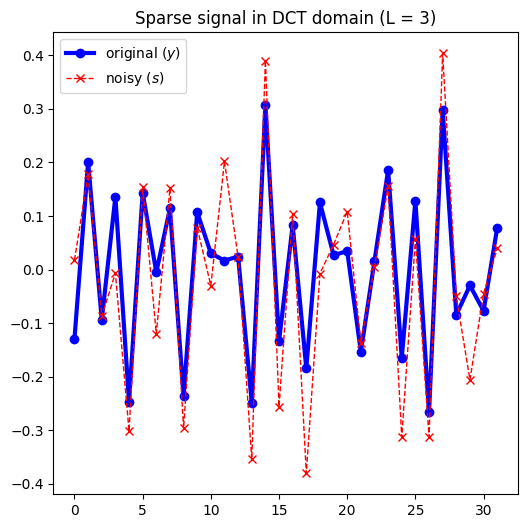

In [8]:
LN_WDT = 2
MRK_SZ = 10

plt.figure(figsize=(6, 6))
plt.plot(y, 'b-o', linewidth=LN_WDT+1)
plt.plot(s, 'r--x', linewidth=LN_WDT-1)
plt.title(f'Sparse signal in DCT domain (L = {L:.0f})')
plt.legend([
    r'original ($y$)',
    r'noisy ($s$)',
])

### Implement the DCT denoising

DCT denoising is expected to be very effective on $s$!

**Analysis**: compute the coefficients w.r.t. $D$

In [ ]:
x = D.T @ s

**Hard Thresholding**: keep only the $L$ largest coefficients (absolute value)

In [10]:
x_hat = np.zeros_like(x)
# Keep only the L largest coefficients in absolute value
idxs = np.argsort(np.abs(x))[-L:]
x_hat[idxs] = x[idxs]

**Synthesis**: invert the transform

In [ ]:
s_hat = D @ x_hat

Plot the results:
- are the denoising performance good?
- are the original coefficients $x_{orig}$ recovered by $\hat x$?

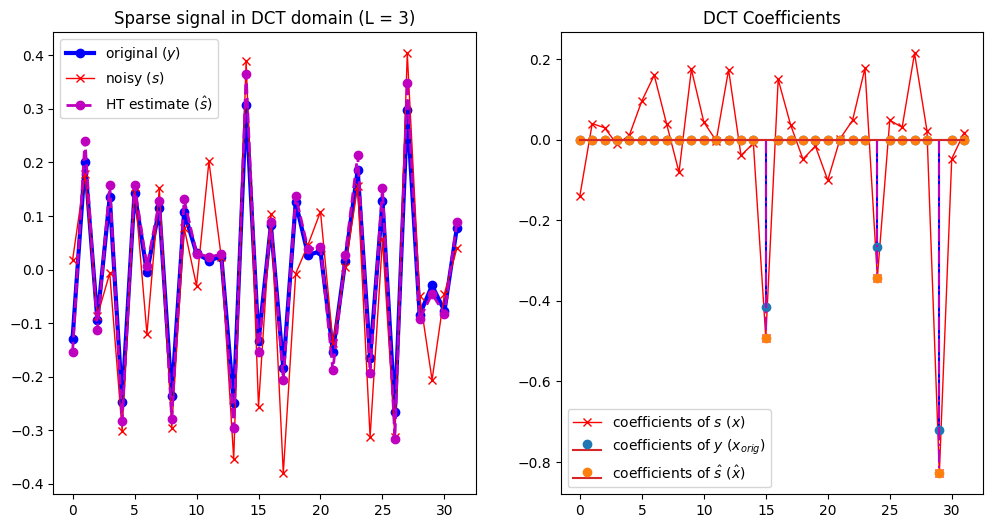

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].plot(y, 'b-o', linewidth=LN_WDT+1)
ax[0].plot(s, 'r-x', linewidth=LN_WDT-1)
ax[0].plot(s_hat, 'm--o', linewidth=LN_WDT)
ax[0].set_title(f'Sparse signal in DCT domain (L = {L:.0f})')
ax[0].legend([
    r'original ($y$)',
    r'noisy ($s$)',
    r'HT estimate ($\hat{s}$)'
])


ax[1].plot(x, 'r-x', linewidth=LN_WDT-1)
ax[1].stem(x_orig, linefmt='b-', markerfmt='C0o')
ax[1].stem(x_hat, linefmt='m-.', markerfmt='C1o')
ax[1].set_title('DCT Coefficients')
ax[1].legend([
    r'coefficients of $s$ ($x$)',
    r'coefficients of $y$ ($x_{orig}$)',
    r'coefficients of $\hat{s}$ ($\hat{x}$)'
])

With very low noise (e.g. AWGN with $\sigma = 0.01$), denoising performance 
is very good: all coefficients of $x_{orig}$ are recovered by $\hat x$ 
,with very good approximation, in the DCT domain and the overlap among $s,\hat{s}$ and $y$ in the signal domain is very close

With stronger noise (e.g. AWGN with $\sigma = 0.10$), Hard Thresholding can
still recover the support of $x_{orig}$, but reconstruction is no longer perfect 
because the non-zero coefficients of $\hat x$ are affected by noise

With very high noise (e.g. AWGN with $\sigma = 1.0$), DCT denoising fails to recover the support of $x_{orig}$, retaining some non-zero coefficients in $x_hat$ that are due only to noise

# Sparsity w.r.t redundant dictionary $A = [C,D]$

In this section you will perform the same denoising as in the previous section with the only difference that the signal $s = y + \eta$ that you will generate is sparse w.r.t. a redundant dictionary $A=[C, D] \in\mathbb{R}^{M \times N}$, where $C\in\mathbb{R}^{M\times M}$ is the matrix representity the canonical basis, and $D\in\mathbb{R}^{M\times M}$ is the usual 1D-DCT matrix. Therefore $A$ is a rectangular matrix, since $M < N$.

To generate signals that are sparse w.r.t. $A=[C, D]$, at first generate a signal $y$ that is $L-1$ sparse w.r.t. $D$ as you have done in the previous section. Then, add a spike to $y$ that is sparse w.r.t. $A$. Bear in mind that the spike is to be considered a signal to be reconstructed, rather than noise.

Generate the standard orthonormal basis

Text(0.5, 1.0, 'Canonical Basis (N = 32)')

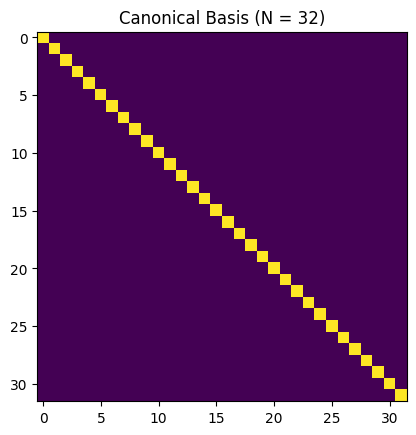

In [13]:
C = np.zeros((M, M))
for i in range(M):
    C[i, i] = 1.0

plt.figure(5)
plt.imshow(C)
plt.title(f'Canonical Basis (N = {M})')



Generate a signal that is sparse w.r.t. D

In [14]:
x_orig = np.zeros(N)
idxs = np.random.choice(M, L, replace=False)
x_orig[idxs] = np.random.uniform(-1.0, 1.0, size=(L,))
y = D @ x_orig

Randomly place a spike in the first 20 samples of $y$


In [ ]:
# Choose spike location
spikeLocation = np.random.randint(0, 20)
# Modify the signal intensity at spikeLocation
l = np.random.uniform(1.0, 5.0)
y[spikeLocation] = l * 1.0

Add noise to the signal

In [ ]:
s = y + np.random.normal(0.0, sigma_noise, size=(M,))

Perform hard thresholding by keeping the largest $L$ coefficients w.r.t. $D$ (not $A$!)

In [ ]:
# Compute the coefficients w.r.t. D
x = D.T @ s

# Keep only the L largest coefficients in absolute value
x_hat = np.zeros_like(x)
idxs = np.argsort(np.abs(x))[-L:]
x_hat[idxs] = x[idxs]

# Invert the transformation
s_hat = D @ x_hat

Plot the results and compare them to the one obtained in the previous section.

Is the signal $s$ denoised properly?

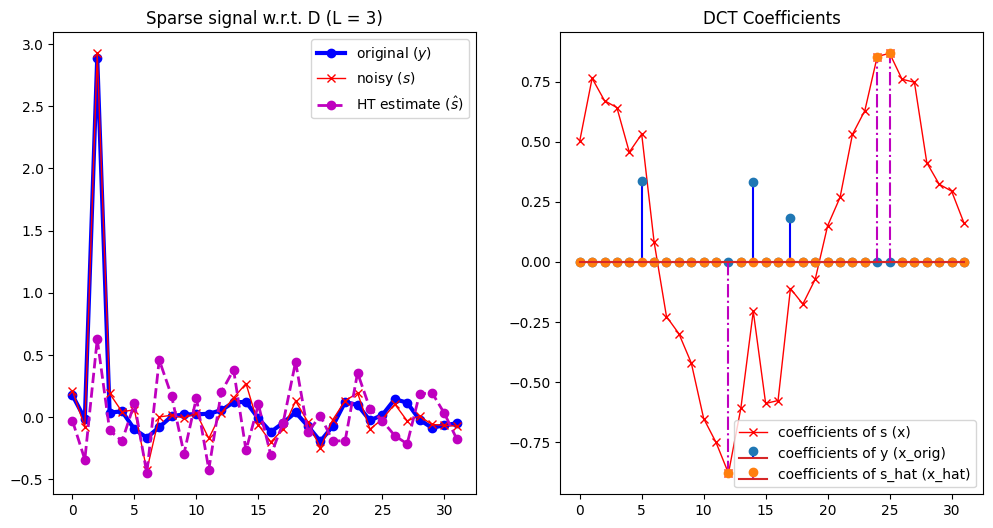

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].plot(y, 'b-o', linewidth=LN_WDT+1)
ax[0].plot(s, 'r-x', linewidth=LN_WDT-1)
ax[0].plot(s_hat, 'm--o', linewidth=LN_WDT)
ax[0].set_title(f'Sparse signal w.r.t. D (L = {L:.0f})')
ax[0].legend([
    r'original ($y$)',
    r'noisy ($s$)',
    r'HT estimate ($\hat{s}$)'
])


ax[1].plot(x, 'r-x', linewidth=LN_WDT-1)
ax[1].stem(x_orig, linefmt='b-', markerfmt='C0o')
ax[1].stem(x_hat, linefmt='m-.', markerfmt='C1o')
ax[1].set_title('DCT Coefficients')
ax[1].legend(['coefficients of s (x)', 'coefficients of y (x_orig)',
             'coefficients of s_hat (x_hat)'])

The signal $s$ is not denoised properly because,  after adding a spike at a random sample of $y$, it does not admit a sparse 
representation with respect to the 1D-DCT basis $D$.  

## Tichonov Regularization


Compute the representation w.r.t. $A = [C, D]$ using Tichonov's regularization (try differente value for $\lambda$)

In [19]:
A = np.concatenate([C, D], axis=1)
lmbda = 1
x_hat_tic = np.linalg.solve((A.T @ A + lmbda * np.eye(2 * N)), (A.T @ s))
s_hat_tic = A @ x_hat_tic

Show the results

Text(0.5, 1.0, 'Coefficients w.r.t. A')

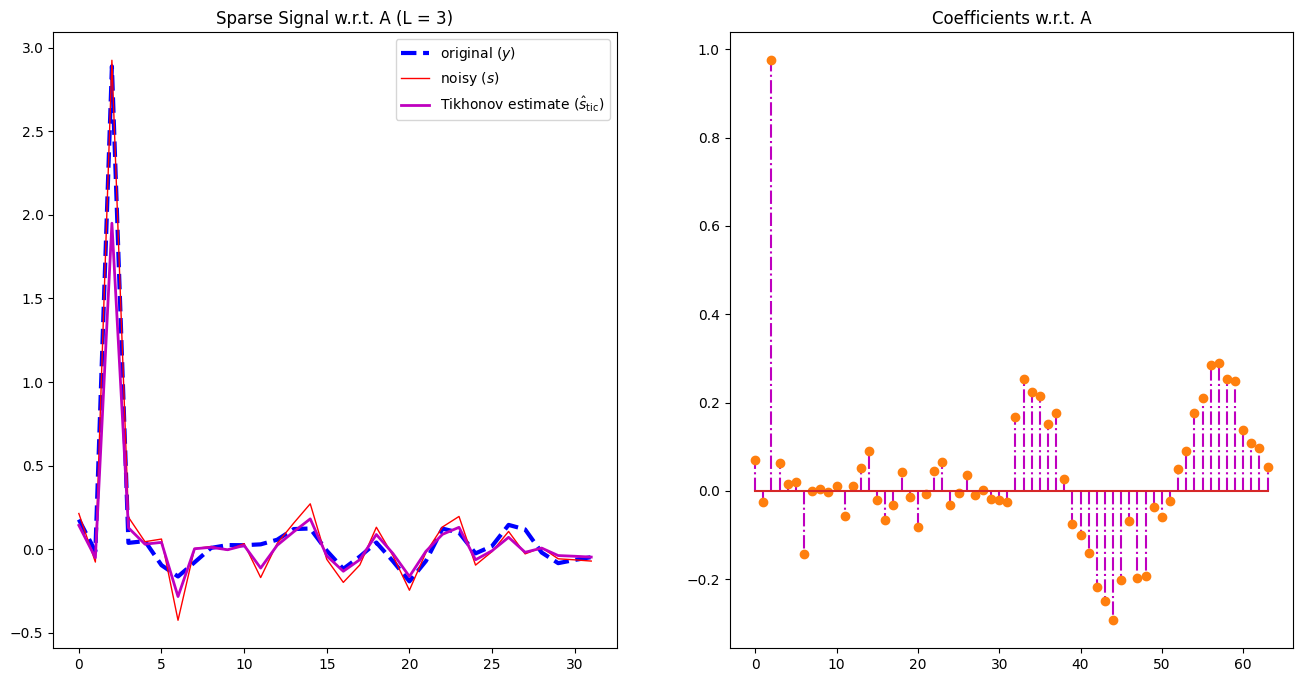

In [20]:
LN_WDT = 2
MRK_SZ = 10

fix, ax = plt.subplots(1, 2, figsize=(16, 8))
ax[0].plot(y, 'b--', linewidth=LN_WDT + 1)
ax[0].plot(s, 'r-', linewidth=LN_WDT - 1)
ax[0].plot(s_hat_tic, 'm-', linewidth=LN_WDT)
ax[0].set_title(f'Sparse Signal w.r.t. A (L = {L:.0f})')
ax[0].legend([
    r'original ($y$)',
    r'noisy ($s$)',
    r'Tikhonov estimate ($\hat{s}_{\mathrm{tic}}$)'
])

ax[1].stem(x_hat_tic, linefmt='m-.', markerfmt='C1o')
ax[1].set_title('Coefficients w.r.t. A')